In [2]:
library(phyloseq)
library(biomformat)
library(ggplot2)
library(vegan)
library(limma)
library(edgeR)
library(pheatmap)
library(DESeq2)
library(ggpubr)
library(dplyr)
library(tidyr)
library(gridExtra)
library(ggExtra)
library(ggforce)
library(tidyverse)
library(viridis)
library(wesanderson)

In [3]:
# Step 1: Import Data and Preprocess Sample Names
# Import the BIOM file to create a phyloseq object
biom_file <- "/home/gamorten/Quals/results/taxonomic_profile/combined_tables/kraken2_combined.biom"
physeq <- import_biom(biom_file)

# Clean sample names to extract only the part before the first underscore
sample_names(physeq) <- unlist(lapply(sample_names(physeq), function(x) sub("_.*", "", x)))

# Load sample metadata and merge with the phyloseq object
sample_metadata <- read.csv("/home/gamorten/Quals/metadata.csv", header = TRUE, row.names = 1)
sample_data_ps <- sample_data(sample_metadata)
physeq <- merge_phyloseq(physeq, sample_data_ps)

#Make batch a factor for quality control
sample_data(physeq)$batch <- as.factor(sample_data(physeq)$batch)

# Rename tax table columns to be informative
tax_table_df <- as.data.frame(tax_table(physeq))
colnames(tax_table_df) <- c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species")
tax_table(physeq) <- tax_table(as.matrix(tax_table_df))

# # Keep samples with at least 500 reads
# physeq <- prune_samples(sample_sums(physeq) >= 500, physeq)

# # Filter out very low abundance taxa
# physeq_filtered <- filter_taxa(physeq, function(x) sum(x > 0) >= 2 & sum(x) >= 5, prune = TRUE)

# Prune any taxa with NA names in any rank
physeq_cleaned <- subset_taxa(physeq, !apply(tax_table(physeq), 1, function(row) {
  any(is.na(row) | row == "")
}))

physeq
physeq_cleaned


Warning message in strsplit(conditionMessage(e), "\n"):
“unable to translate 'lexical error: invalid char in json text.
                                       <89>HDF                        (right here) ------^
' to a wide string”
Warning message in strsplit(conditionMessage(e), "\n"):
“input string 1 is invalid”


phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 16580 taxa and 73 samples ]
sample_data() Sample Data:       [ 73 samples by 38 sample variables ]
tax_table()   Taxonomy Table:    [ 16580 taxa by 7 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 16580 taxa and 73 samples ]
sample_data() Sample Data:       [ 73 samples by 38 sample variables ]
tax_table()   Taxonomy Table:    [ 16580 taxa by 7 taxonomic ranks ]

In [4]:
# Convert taxonomic table to a data frame
tax_table_df <- as.data.frame(tax_table(physeq_cleaned))

# Convert OTU table to a data frame
otu_table_df <- as.data.frame(otu_table(physeq_cleaned))

# Convert sample metadata to a data frame
sample_metadata_df <- as.data.frame(sample_data(physeq_cleaned))


In [5]:
# Check for NA values in the taxonomic table
na_count_tax <- sum(is.na(tax_table_df))
print(paste("Number of NA values in the taxonomic table:", na_count_tax))

# Check for NA values column-wise
na_by_column_tax <- colSums(is.na(tax_table_df))
print("Number of NA values in each column of the taxonomic table:")
print(na_by_column_tax)


[1] "Number of NA values in the taxonomic table: 0"
[1] "Number of NA values in each column of the taxonomic table:"
Kingdom  Phylum   Class   Order  Family   Genus Species 
      0       0       0       0       0       0       0 


In [6]:

# Total counts per sample
otu_sample_sums <- sample_sums(physeq_cleaned)
print("Total counts per sample:")
print(summary(otu_sample_sums))

# Total counts per taxon
otu_taxa_sums <- taxa_sums(physeq_cleaned)
print("Total counts per taxon:")
print(summary(otu_taxa_sums))


[1] "Total counts per sample:"
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
  282627  4632164  6216377  9296499 14189781 27958844 
[1] "Total counts per taxon:"
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
       1       34      742    40932     2314 48618986 


In [7]:
# Test for batch effects using PERMANOVA before correction
dist_matrix_before <- phyloseq::distance(physeq_cleaned, method = "bray")
sample_data_df_before <- as(sample_data(physeq_cleaned), "data.frame")
adonis_before <- adonis2(dist_matrix_before ~ batch, data = sample_data_df_before)
print(adonis_before)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

adonis2(formula = dist_matrix_before ~ batch, data = sample_data_df_before)
         Df SumOfSqs      R2      F Pr(>F)    
Model     1   2.6171 0.15117 12.644  0.001 ***
Residual 71  14.6955 0.84883                  
Total    72  17.3127 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Correct batch affects with log transformation and rescaling to psuedo-counts

In [8]:
# Correct Batch Effects Using Limma-Voom
# Extract the OTU count table from phyloseq
otu_counts <- as(otu_table(physeq_cleaned), "matrix")
batch <- sample_data(physeq_cleaned)$batch
group <- sample_data(physeq_cleaned)$group  # Condition grouping (e.g., case/control)

# Create DGEList object and normalize counts
y <- DGEList(counts = otu_counts)
y <- calcNormFactors(y)

# Use voom to transform count data for linear modeling
design <- model.matrix(~ batch + group)
v <- voom(y, design, plot = FALSE)

# Fit the linear model and correct for batch effects
fit <- lmFit(v, design)
corrected_logCPM <- removeBatchEffect(v$E, batch = batch)

# Create a new phyloseq object with the corrected logCPM values
physeq_corrected <- physeq_cleaned  # Copy the original phyloseq object
otu_table(physeq_corrected) <- otu_table(corrected_logCPM, taxa_are_rows = TRUE)

# Convert log-transformed values back to original scale through exponentiation
exp_corrected <- exp(corrected_logCPM)

# Create a new phyloseq object with the exponentiated values
otu_table(physeq_corrected) <- otu_table(exp_corrected, taxa_are_rows = TRUE)


In [9]:
# Test for batch effects using PERMANOVA after correction
dist_matrix_after <- phyloseq::distance(physeq_corrected, method = "bray")
sample_data_df_after <- as(sample_data(physeq_corrected), "data.frame")
adonis_after <- adonis2(dist_matrix_after ~ batch, data = sample_data_df_after)
print(adonis_after)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

adonis2(formula = dist_matrix_after ~ batch, data = sample_data_df_after)
         Df SumOfSqs      R2      F Pr(>F)
Model     1    0.386 0.01601 1.1549  0.273
Residual 71   23.730 0.98399              
Total    72   24.116 1.00000              


In [11]:
physeq_corrected

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 16580 taxa and 73 samples ]
sample_data() Sample Data:       [ 73 samples by 38 sample variables ]
tax_table()   Taxonomy Table:    [ 16580 taxa by 7 taxonomic ranks ]

In [16]:
## Inspect and prepare metadata
md <- as.data.frame(sample_data(physeq_corrected))

# # Check labels
table(md$Hypertension, useNA = "ifany")
table(md$GDM, useNA = "ifany")

# # Standardize as factors (optional but recommended)
# md$Hypertension <- factor(md$Hypertension, levels = c("No", "Yes"))
# md$GDM          <- factor(md$GDM, levels = c("No", "Yes"))

# sample_data(physeq_corrected) <- sample_data(md)

# ## -------------------------
# ## Control vs GH
# ## -------------------------

# physeq_GH <- subset_samples(
#   physeq_corrected,
#   Hypertension == "Yes" | (Hypertension == "No" & GDM == "No")
# )

# # Create grouping variable
# md_GH <- as.data.frame(sample_data(physeq_GH))
# md_GH$Group_GH <- ifelse(md_GH$Hypertension == "Yes", "GH", "Control")
# md_GH$Group_GH <- factor(md_GH$Group_GH, levels = c("Control", "GH"))
# sample_data(physeq_GH) <- sample_data(md_GH)

# # Sanity check
# table(md_GH$Group_GH)


## -------------------------
## Control vs GDM
## -------------------------

# physeq_GDM <- subset_samples(
#   physeq_corrected,
#   GDM == "Yes" | (Hypertension == "No" & GDM == "No")
# )

# # Create grouping variable
# md_GDM <- as.data.frame(sample_data(physeq_GDM))
# md_GDM$Group_GDM <- ifelse(md_GDM$GDM == "Yes", "GDM", "Control")
# md_GDM$Group_GDM <- factor(md_GDM$Group_GDM, levels = c("Control", "GDM"))
# sample_data(physeq_GDM) <- sample_data(md_GDM)

# # Sanity check
# table(md_GDM$Group_GDM)

< table of extent 0 >

< table of extent 0 >

In [ ]:
# Extract alpha diversity metrics 
alpha_df <- estimate_richness(physeq_cleaned, 
                             measures = c("Observed", "Shannon", "Simpson")) %>%
  mutate(SampleID = rownames(.),
         group = sample_data(physeq_cleaned)$group)  # Only group variable

# Reshape for plotting
alpha_long <- alpha_df %>%
  pivot_longer(cols = c(Observed, Shannon, Simpson),
               names_to = "metric",
               values_to = "value")

# Function to calculate p-values (no study adjustment)
calculate_pvals <- function(data) {
  # linear model (no covariates)
  lm_p <- lm(value ~ group, data = data) %>%
    broom::tidy() %>%
    filter(term != "(Intercept)") %>%  # Extract group coefficient
    pull(p.value)
  
  # Mann-Whitney U test (no adjustment)
  mw_p <- wilcox.test(value ~ group, data = data, exact = FALSE)$p.value
  
  data.frame(lm_p = lm_p, mw_p = mw_p)
}

# Calculate p-values for each metric
pval_df <- alpha_long %>%
  group_by(metric) %>%
  group_modify(~ calculate_pvals(.x)) %>%
  mutate(
    lm_p_label = sprintf("#p = %.2e", lm_p),
    mw_p_label = sprintf("$p = %.2e", mw_p)
  )

# plot figure
species_alpha_plot <- ggplot(alpha_long, aes(x = group, y = value, fill = group)) +
  geom_violin(trim = FALSE, scale = "width", width = 0.7) +
  geom_boxplot(width = 0.1, fill = "white") +
  facet_wrap(~ metric, scales = "free_y", nrow = 1) +
  geom_text(
    data = pval_df,
    aes(x = 1.5, y = Inf, label = paste(lm_p_label, "\n", mw_p_label)),
    inherit.aes = FALSE,  
    vjust = 1.5,
    # hjust = -0.00000001,
    size = 3,
    show.legend = FALSE
  ) +  
  scale_fill_manual(values = c("Case" = "#F8766D", "Control" = "#00BFC4")) +
  labs(
    title = "Species Alpha Diversity",
       y = "Diversity Value",
       x = "") +
  theme_minimal() +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    axis.text.x = element_blank(),
    strip.text = element_text(face = "bold"),
    legend.position = "none",
    plot.margin = margin(1, 1, 1, 1, "cm")
  )

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


Square root transformation
Wisconsin double standardization
Run 0 stress 0.1351205 
Run 1 stress 0.1513418 
Run 2 stress 0.1510456 
Run 3 stress 0.1439491 
Run 4 stress 0.1510261 
Run 5 stress 0.1550225 
Run 6 stress 0.146099 
Run 7 stress 0.1560725 
Run 8 stress 0.1569766 
Run 9 stress 0.1526076 
Run 10 stress 0.1568746 
Run 11 stress 0.1464328 
Run 12 stress 0.1592964 
Run 13 stress 0.1511558 
Run 14 stress 0.1600692 
Run 15 stress 0.1541077 
Run 16 stress 0.1485045 
Run 17 stress 0.1574755 
Run 18 stress 0.1463502 
Run 19 stress 0.1557774 
Run 20 stress 0.1440719 
Run 21 stress 0.1507294 
Run 22 stress 0.1529837 
Run 23 stress 0.1447896 
Run 24 stress 0.1536224 
Run 25 stress 0.1555309 
Run 26 stress 0.1518101 
Run 27 stress 0.144362 
Run 28 stress 0.155273 
Run 29 stress 0.1485443 
Run 30 stress 0.1549864 
Run 31 stress 0.1523764 
Run 32 stress 0.1498282 
Run 33 stress 0.1432022 
Run 34 stress 0.14598 
Run 35 stress 0.151091 
Run 36 stress 0.1509829 
Run 37 stress 0.1556698 
Run 38

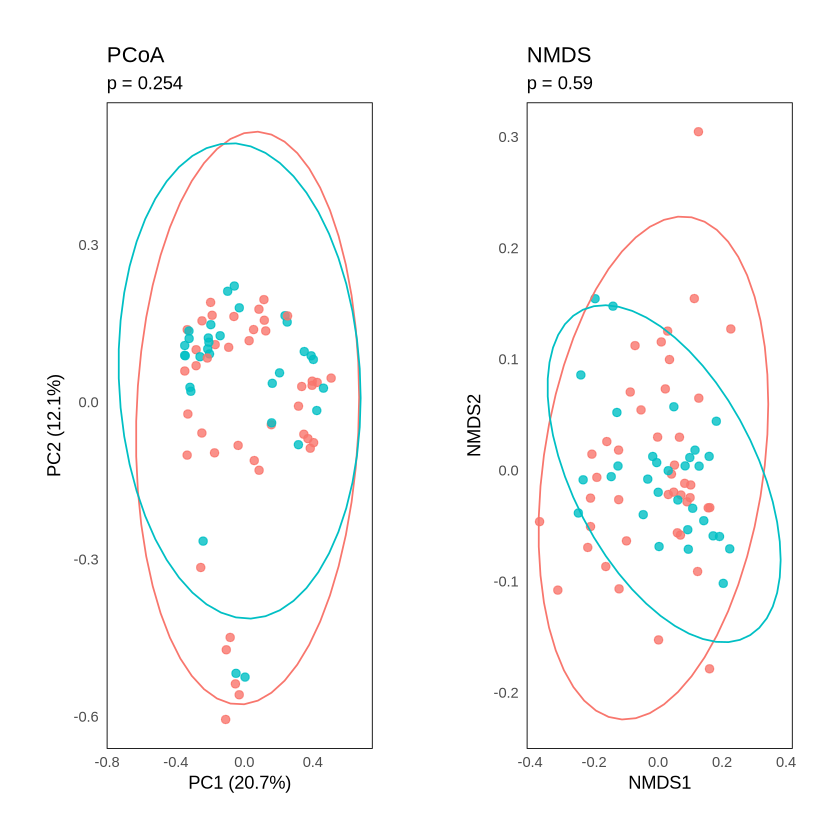

In [ ]:
# Extract metadata
sample_df <- as(sample_data(physeq_corrected), "data.frame")

# ---- PCoA ----
pcoa_ord <- ordinate(physeq_corrected, method = "PCoA", distance = "bray")
pcoa_df <- as.data.frame(pcoa_ord$vectors[, 1:2])
colnames(pcoa_df) <- c("Axis.1", "Axis.2")
pcoa_df$SampleID <- rownames(pcoa_df)
pcoa_df$Group <- sample_df$group[match(pcoa_df$SampleID, rownames(sample_df))]

# MANOVA
manova_pcoa <- summary(manova(cbind(Axis.1, Axis.2) ~ Group, data = pcoa_df), test = "Pillai")
pval_manova_pcoa <- signif(manova_pcoa$stats[1, "Pr(>F)"], 3)

# Variance explained
pcoa_var1 <- round(100 * pcoa_ord$values$Relative_eig[1], 1)
pcoa_var2 <- round(100 * pcoa_ord$values$Relative_eig[2], 1)

p1 <- ggplot(pcoa_df, aes(x = Axis.1, y = Axis.2, color = Group)) +
  geom_point(size = 2, alpha = 0.8) +
  stat_ellipse(type = "norm", level = 0.95) +
  labs(
    title = "PCoA",
    subtitle = paste0("p = ", pval_manova_pcoa),
    x = paste0("PC1 (", pcoa_var1, "%)"),
    y = paste0("PC2 (", pcoa_var2, "%)")
  ) +
  theme_minimal() +
  theme(panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA),
        strip.text = element_text(face = "bold"),
        plot.margin = margin(1, 1, 1, 1, "cm"),
        legend.position = "none")

# ---- NMDS ----
nmds_ord <- ordinate(physeq_corrected, method = "NMDS", distance = "bray", trymax = 100)
nmds_df <- as.data.frame(nmds_ord$points[, 1:2])
colnames(nmds_df) <- c("Axis.1", "Axis.2")
nmds_df$SampleID <- rownames(nmds_df)
nmds_df$Group <- sample_df$group[match(nmds_df$SampleID, rownames(sample_df))]

# MANOVA for NMDS
manova_nmds <- summary(manova(cbind(Axis.1, Axis.2) ~ Group, data = nmds_df), test = "Pillai")
pval_manova_nmds <- signif(manova_nmds$stats[1, "Pr(>F)"], 3)

p2 <- ggplot(nmds_df, aes(x = Axis.1, y = Axis.2, color = Group)) +
  geom_point(size = 2, alpha = 0.8) +
  stat_ellipse(type = "norm", level = 0.95) +
  labs(
    title = "NMDS",
    subtitle = paste0("p = ", pval_manova_nmds, ""),
    x = "NMDS1",
    y = "NMDS2"
  ) +
  theme_minimal() +
  theme(panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA),
        strip.text = element_text(face = "bold"),
        plot.margin = margin(1, 1, 1, 1, "cm"),
        legend.position = "none")

# ---- Arrange Side-by-Side ----
gridExtra::grid.arrange(p1, p2, nrow = 1)



In [ ]:
# PERMANOVA
dist <- phyloseq::distance(physeq_corrected, method = "bray")
permanova <- adonis2(dist ~ group, data = sample_df)
pval <- signif(permanova$`Pr(>F)`[1], 3)
print(paste0("PERMANOVA p = ", pval))

[1] "PERMANOVA p = 0.426"


In [ ]:
# Remove rank prefixes
tax_table(physeq_corrected)[, "Phylum"] <- gsub("^p__|__", "", tax_table(physeq_corrected)[, "Phylum"])

# Normalize to relative abundance
physeq_rel <- transform_sample_counts(physeq_corrected, function(x) x / sum(x))

# Subset to Firmicutes + Bacteroidetes, including synonyms
physeq_fb <- subset_taxa(physeq_rel, Phylum %in% c("Firmicutes", "Bacteroidetes", "Bacillota", "Bacteroidota"))

# Aggregate to phylum level
physeq_phylum <- tax_glom(physeq_fb, taxrank = "Phylum")

# Extract OTU table and assign phylum names
otu_df <- as.data.frame(otu_table(physeq_phylum))
phylum_names <- tax_table(physeq_phylum)[, "Phylum"]
rownames(otu_df) <- as.character(phylum_names)

# Transpose to get samples as rows
otu_df_t <- as.data.frame(t(otu_df))
otu_df_t$Sample <- rownames(otu_df_t)

# Merge with sample metadata
meta_df <- as(sample_data(physeq_phylum), "data.frame")
meta_df$Sample <- rownames(meta_df)
merged_df <- merge(otu_df_t, meta_df, by = "Sample")

# Identify correct column names for Firmicutes and Bacteroidetes (support synonyms)
firms <- intersect(c("Firmicutes", "Bacillota"), colnames(merged_df))
bacts <- intersect(c("Bacteroidetes", "Bacteroidota"), colnames(merged_df))

if (length(firms) == 0 | length(bacts) == 0) {
  stop("Could not find both Firmicutes/Bacillota and Bacteroidetes/Bacteroidota in data.")
}

# Calculate FB ratio
merged_df$FB_ratio <- merged_df[[firms[1]]] / merged_df[[bacts[1]]]


In [ ]:
# Reshape to long format
df_long <- merged_df %>%
  select(Sample, group, all_of(firms[1]), all_of(bacts[1]), FB_ratio) %>%
  rename(Firmicutes = all_of(firms[1]), Bacteroidetes = all_of(bacts[1])) %>%
  pivot_longer(cols = c("Firmicutes", "Bacteroidetes"),
               names_to = "Phylum", values_to = "Abundance")

# Wisorize outliers
merged_df$FB_ratio_winsor <- pmin(merged_df$FB_ratio, quantile(merged_df$FB_ratio, 0.95))

# Calculate mean F/B per group
fb_summary <- merged_df %>%
  group_by(group) %>%
  summarise(mean_FB = mean(FB_ratio_winsor, na.rm = TRUE))

# Perform Wilcoxon test
wilcox_result <- wilcox.test(FB_ratio_winsor ~ group, data = merged_df, exact = FALSE)
pval <- signif(wilcox_result$p.value, 3)

# Plot stacked bar
fb_plot <- ggplot(df_long, aes(x = group, y = Abundance, fill = Phylum)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", color = "black") +
  geom_text(data = fb_summary,
            aes(x = group, y = 1.05, label = paste0("F/B = ", round(mean_FB, 2))),
            inherit.aes = FALSE, size = 4, vjust = 0) +
  annotate("text", x = 1.5, y = 1.15,
           label = paste0("p = ", pval),
           size = 4, fontface = "italic") +
  # scale_fill_manual(values=wes_palette(name="Cavalcanti1")) +
  scale_fill_viridis_d(option = "D") +
  labs(
       x = "Group", y = "Mean Relative Abundance") +
  theme_minimal() +
  theme(panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA),
        axis.ticks = element_line(color = "black"),
        legend.position = "right")
print(paste0("Wilcoxon p-value: ", pval))

[1] "Wilcoxon p-value: 0.482"


In [ ]:
# Agglomerate to Genus level (or another rank if needed)
physeq_Genus <- tax_glom(physeq_rel, taxrank = "Genus")

# Melt the data for ggplot
df_Genus <- psmelt(physeq_Genus)

# Clean Genus names (remove s__ prefix if needed)
df_Genus$Genus <- gsub("g__|__", "", as.character(df_Genus$Genus))

In [ ]:
# Identify top 5–6 Genus by mean abundance
top_Genus <- df_Genus %>%
  group_by(Genus) %>%
  summarise(mean_abundance = mean(Abundance)) %>%
  arrange(desc(mean_abundance)) %>%
  slice(1:6) %>%
  pull(Genus)

# Replace other Genus with "Other" category
df_Genus$Genus <- ifelse(df_Genus$Genus %in% top_Genus,
                              df_Genus$Genus, "Other")

In [ ]:
# Summarize relative abundance per group
df_summary <- df_Genus %>%
  group_by(Sample, group, Genus) %>%
  summarise(Abundance = sum(Abundance), .groups = "drop")

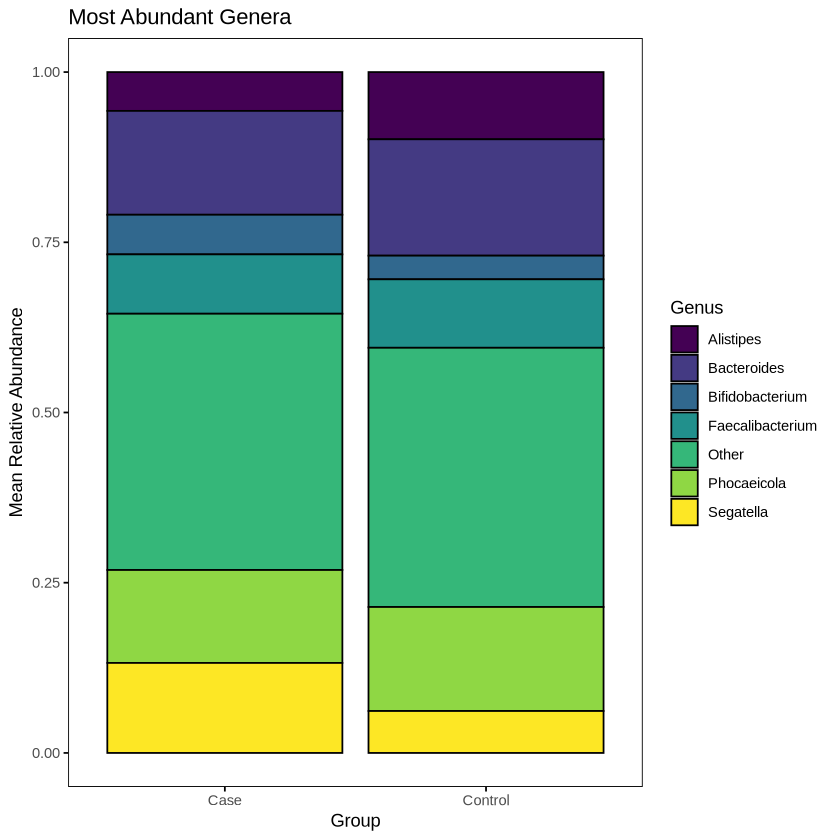

In [ ]:
# Plot stacked barplot
species_plot <- ggplot(df_summary, aes(x = group, y = Abundance, fill = Genus)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", color = "black") +
  labs(title = "Most Abundant Genera",
       x = "Group", y = "Mean Relative Abundance") +
  theme_minimal() +
  scale_fill_viridis_d(option = "D") +
  theme(panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA),
        axis.ticks = element_line(color = "black"),
        legend.position = "right")
species_plot

In [ ]:
# ---- Load Libraries ----
library(dplyr)
library(tidyr)
library(ggplot2)
library(vegan)
library(broom)
library(readr)

# ---- Load Pathway Abundance Table ----
path_table <- read_tsv("/home/gamorten/Quals/results/functional_profile/combined_tables/combined_pathabundance_relab_unstratified.tsv")

# Set rownames and drop first column (pathway ID)
rownames(path_table) <- path_table[[1]]
path_table <- path_table[, -1]

# Transpose to samples x pathways
path_df_t <- as.data.frame(t(path_table))
path_df_t$SampleID <- rownames(path_df_t)

# Clean sample names to match metadata
path_df_t$SampleID <- sub("_.*", "", path_df_t$SampleID)

# ---- Load Metadata ----
meta <- read.csv("/home/gamorten/Quals/metadata.csv", header = TRUE)

# ---- Compute Diversity Metrics ----
# Get only numeric matrix for vegan
abundance_matrix <- path_df_t[, !colnames(path_df_t) %in% c("SampleID")]

# Richness: Number of non-zero pathways
richness <- rowSums(abundance_matrix > 0)
# Shannon and Simpson indices
shannon <- diversity(abundance_matrix, index = "shannon")
simpson <- diversity(abundance_matrix, index = "simpson")

# Combine diversity metrics
diversity_df <- data.frame(
  SampleID = path_df_t$SampleID,
  Richness = richness,
  Shannon = shannon,
  Simpson = simpson
)

# Merge with metadata
diversity_df <- merge(diversity_df, meta[, c("mbi_sample_id", "group")],
                      by.x = "SampleID", by.y = "mbi_sample_id")

# ---- Reshape for Plotting ----
alpha_long <- diversity_df %>%
rename(Observed = Richness) %>%
  pivot_longer(cols = c(Observed, Shannon, Simpson),
               names_to = "metric",
               values_to = "value")

# ---- Compute p-values ----
calculate_pvals <- function(data) {
  lm_p <- lm(value ~ group, data = data) %>%
    broom::tidy() %>%
    filter(term != "(Intercept)") %>%
    pull(p.value)
  
  mw_p <- wilcox.test(value ~ group, data = data, exact = FALSE)$p.value
  
  data.frame(lm_p = lm_p, mw_p = mw_p)
}

pval_df <- alpha_long %>%
  group_by(metric) %>%
  group_modify(~ calculate_pvals(.x)) %>%
  mutate(
    lm_p_label = sprintf("#p = %.2e", lm_p),
    mw_p_label = sprintf("$p = %.2e", mw_p)
  )


# ---- Plot ----
pathway_alpha_plot <- ggplot(alpha_long, aes(x = group, y = value, fill = group)) +
  geom_violin(trim = FALSE, scale = "width", width = 0.7) +
  geom_boxplot(width = 0.1, fill = "white") +
  facet_wrap(~ metric, scales = "free_y", nrow = 1) +
  geom_text(
    data = pval_df,
    aes(x = 1.5, y = Inf, label = paste(lm_p_label, "\n", mw_p_label)),
    inherit.aes = FALSE,  
    vjust = 1.5,
    # hjust = -0.00000001,
    size = 3,
    show.legend = FALSE
  ) +
  scale_fill_manual(values = c("Case" = "#F8766D", "Control" = "#00BFC4")) +
  labs(
    title = "Pathway Alpha Diversity",
    y = "Diversity Value",
    x = ""
  ) +
  theme_minimal() +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    axis.text.x = element_blank(),
    strip.text = element_text(face = "bold"),
    legend.position = "none",
    plot.margin = margin(1, 1, 1, 1, "cm")
  )


Rows: 490 Columns: 73
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (1): # Pathway
dbl (72): S00JD-0001_S14_L001_concatenated_Abundance, S00JD-0002_S15_L001_co...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“Setting row names on a tibble is deprecated.”


In [ ]:
dim(abundance_matrix)          # Should be: n_samples × n_features
nrow(merged_df)                # Should match n_samples


[1]  72 490

[1] 73

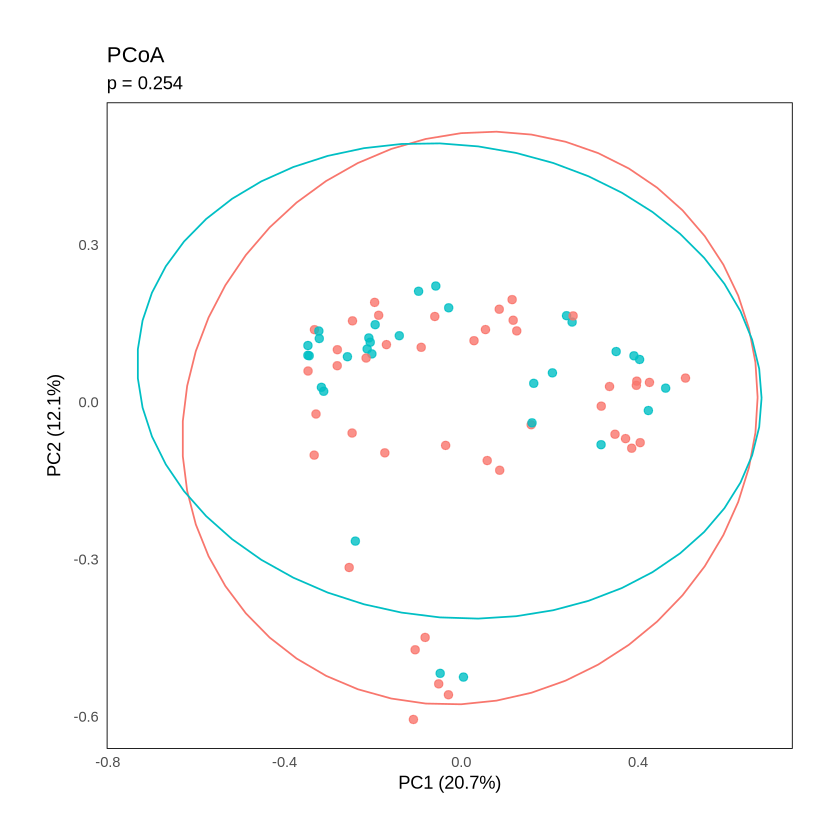

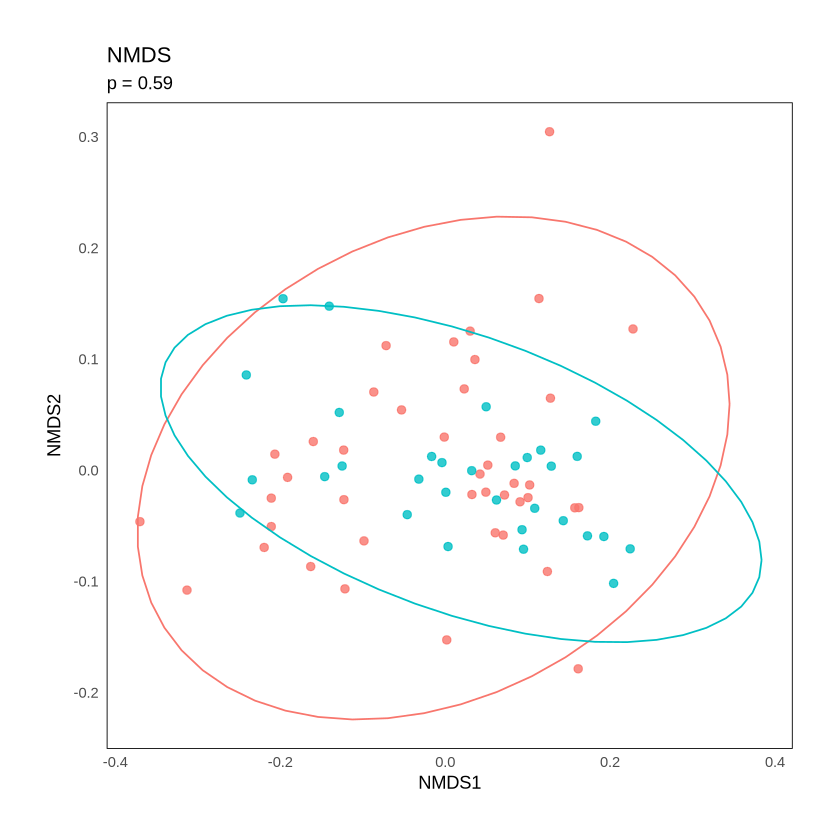

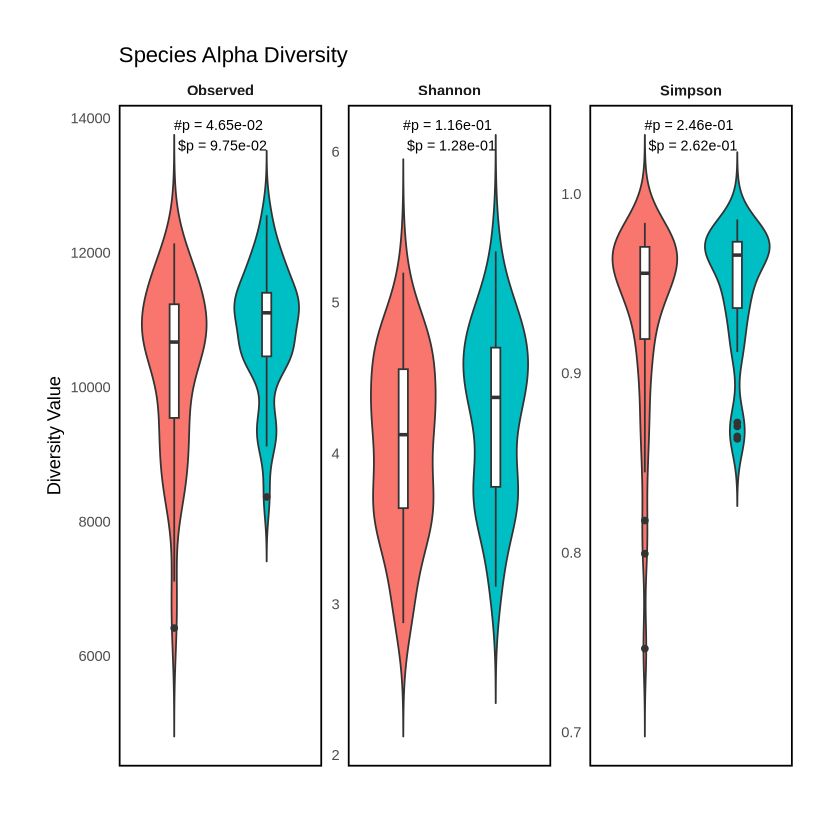

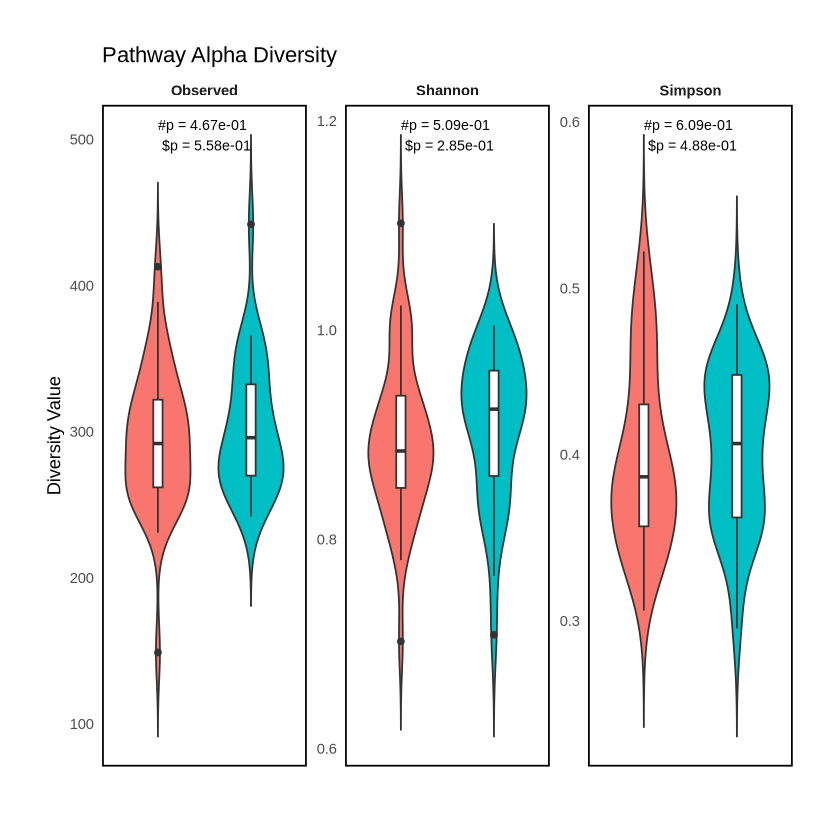

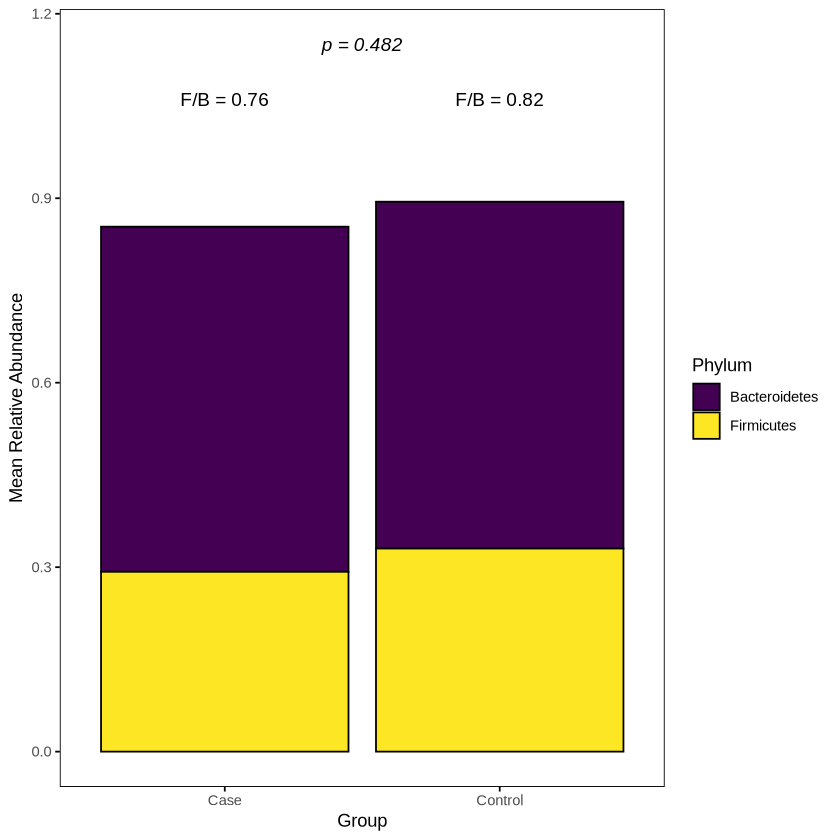

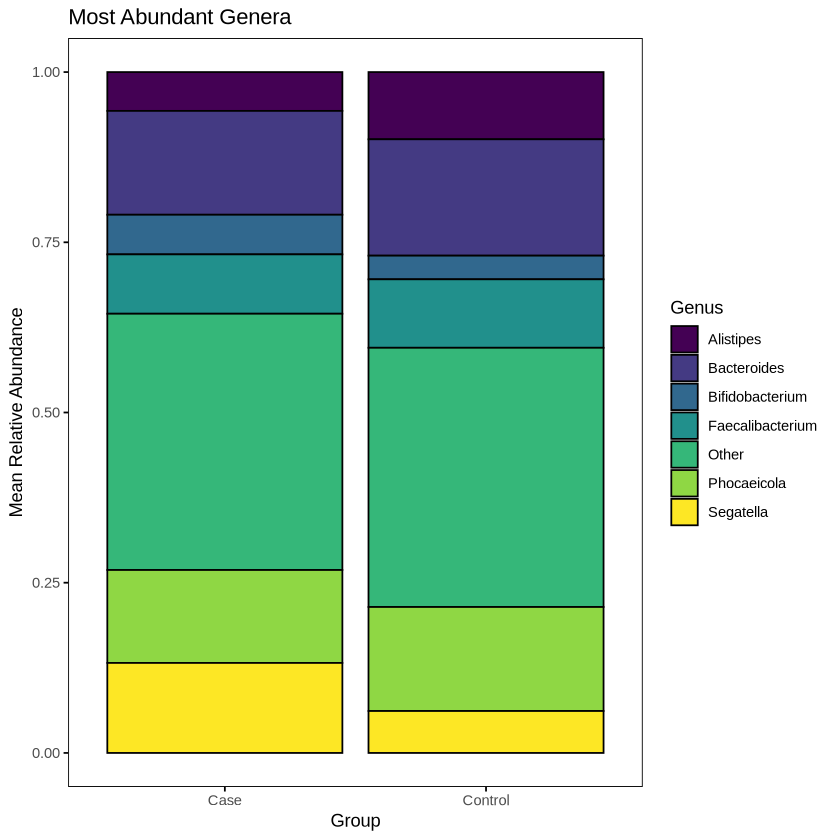

In [ ]:
p1
p2
species_alpha_plot
pathway_alpha_plot
fb_plot
species_plot

In [ ]:
# Full Genus + Species (most specific)
target_species <- c("Prevotella copri", "Bacteroides fragilis", "Bifidobacterium longum",
                    "Lactobacillus reuteri", "Akkermansia muciniphila", "Ruminococcus bromii",
                    "Faecalibacterium prausnitzii", "Escherichia coli", "Clostridium difficile",
                    "Roseburia intestinalis", "Collinsella aerofaciens", "Dialister invisus")

# Genus-level only (fallback or genus-specific interest)
target_genera <- c("Blautia", "Streptococcus", "Alistipes", "Segatella",
                   "Veillonella", "Desulfovibrio", "Parabacteroides")

# Access tax_table and convert to data frame
tax_clean <- as.data.frame(tax_table(physeq_corrected))

# Remove prefixes like k__, p__, c__, etc. from all columns
tax_clean[] <- lapply(tax_clean, function(x) gsub("^[a-z]__|__", "", x))

# Replace tax_table in your phyloseq object
tax_table(physeq_corrected) <- tax_table(as.matrix(tax_clean))
tax_df <- as.data.frame(tax_table(physeq_corrected))
tax_df$taxa_label <- with(tax_df, paste(Genus, Species, sep = " "))

matched_otus <- rownames(tax_df)[
  tax_df$taxa_label %in% target_species |
  tax_df$Genus %in% target_genera
]

physeq_subset <- prune_taxa(matched_otus, physeq_corrected)
tax_subset <- as.data.frame(tax_table(physeq_subset))


In [ ]:
# Step 1: Transform to relative abundance (already done)
physeq_rel <- transform_sample_counts(physeq_subset, function(x) x / sum(x))

# Step 2: Melt to long format
df_long <- psmelt(physeq_rel)
df_long$taxa_label <- paste(df_long$Genus, df_long$Species)

# Step 3: Filter to taxa of interest
df_filtered <- df_long %>%
  filter(taxa_label %in% c(target_species, paste(target_genera, "")))

# Step 4: Average within each group per taxon
df_summary <- df_filtered %>%
  group_by(group, taxa_label) %>%
  summarise(mean_abundance = mean(Abundance), .groups = "drop")

# Step 5: Normalize to sum to 1 per group
df_summary <- df_summary %>%
  group_by(group) %>%
  mutate(prop_abundance = mean_abundance / sum(mean_abundance))

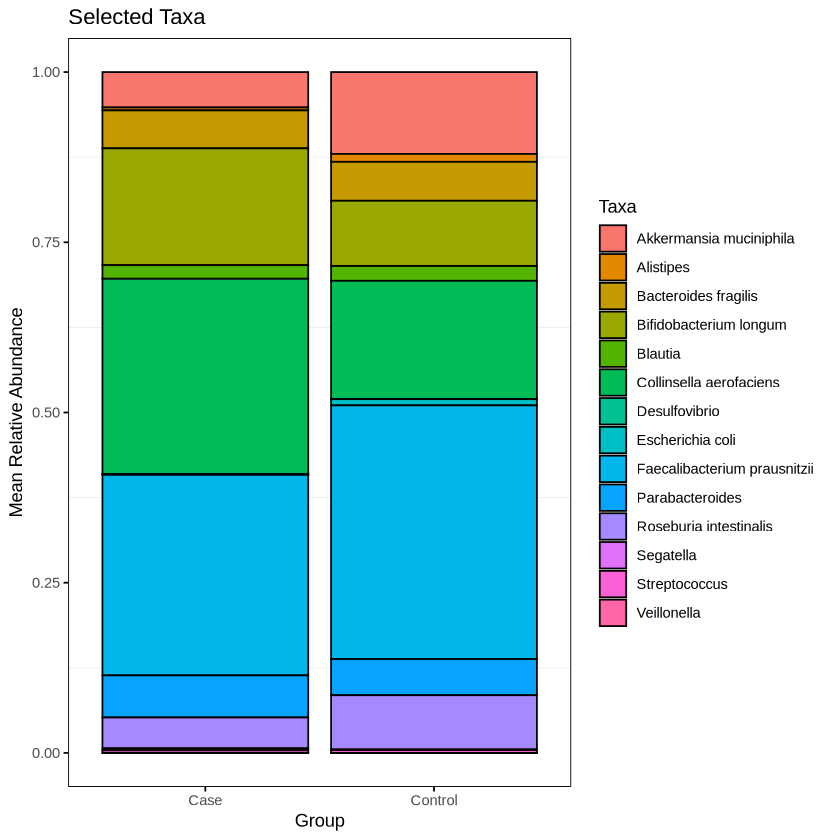

In [ ]:
ggplot(df_summary, aes(x = group, y = prop_abundance, fill = taxa_label)) +
  geom_bar(stat = "identity", position = "stack", color ="black") +
  labs(
    title = "Selected Taxa",
    x = "Group",
    y = "Mean Relative Abundance",
    fill = "Taxa"
  ) +
  theme_minimal() +
  theme(
    panel.grid.major = element_blank(),
    panel.border = element_rect(color = "black", fill = NA),
    axis.ticks = element_line(color = "black")
  )

In [ ]:
df_summary

group,taxa_label,mean_abundance,prop_abundance
<chr>,<chr>,<dbl>,<dbl>
Case,Akkermansia muciniphila,2.296240e-02,5.197047e-02
Case,Alistipes,1.913946e-03,4.331808e-03
Case,Bacteroides fragilis,2.461613e-02,5.571335e-02
Case,Bifidobacterium longum,7.582496e-02,1.716136e-01
Case,Blautia,8.790521e-03,1.989546e-02
Case,Collinsella aerofaciens,1.266892e-01,2.867339e-01
Case,Desulfovibrio,1.550888e-05,3.510104e-05
Case,Escherichia coli,5.827898e-04,1.319020e-03
Case,Faecalibacterium prausnitzii,1.301135e-01,2.944841e-01


In [ ]:
# Set reference level to "Control"
# Ensure group is a factor with correct reference
sample_data(physeq_corrected)$group <- factor(
  sample_data(physeq_corrected)$group,
  levels = c("Control", "Case")
)

# DESeq2 setup and run
dds <- phyloseq_to_deseq2(physeq_corrected, ~ group)
dds <- DESeq(dds)

# Extract results: control vs case
res <- results(dds, contrast = c("group", "Case", "Control"))
res_df <- as.data.frame(res[order(res$padj, na.last = NA), ]) %>%
  rownames_to_column("Taxon")


converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1483 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [ ]:

# Merge taxonomy
tax_table_df <- as.data.frame(tax_table(physeq_corrected)) %>%
  rownames_to_column("Taxon")

res_annotated <- res_df %>%
  left_join(tax_table_df, by = "Taxon") %>%
  mutate(
    Genus = ifelse(is.na(Genus), "Unclassified", Genus),
    Species = ifelse(is.na(Species), "", Species),
    log2fc_str = paste0("log2FC=", round(log2FoldChange, 2)),
    fdr_str = paste0("FDR=", signif(padj, 2)),
    # label = paste0(Genus, " ", Species, "\n", log2fc_str, " ", fdr_str),
    taxa = paste0(Genus, " ", Species)
  )

# taxa by FDR
all_taxa <- res_annotated$Taxon

# Abundance matrix
otu_df <- as.data.frame(otu_table(physeq_corrected))
if (taxa_are_rows(physeq_corrected)) {
  otu_df <- t(otu_df)
}
otu_df <- as.data.frame(otu_df)
otu_df$SampleID <- rownames(otu_df)

# Reshape and merge
plot_df <- otu_df %>%
  select(all_of(all_taxa), SampleID) %>%
  pivot_longer(cols = -SampleID, names_to = "Taxon", values_to = "abundance")


In [ ]:

# meta_raw <- sample_metadata <- read.csv("/home/gamorten/Quals/metadata.csv", 
# header = TRUE, row.names = 1)
# all(sample_names(physeq_corrected) %in% rownames(meta_raw))
# # should be TRUE for every sample
# sample_data(physeq_corrected) <- sample_data(meta_raw)
# meta_df <- as.data.frame(sample_data(physeq_corrected)) %>%
#   # rownames_to_column("SampleID")
# dim(meta_df)  # should now be 73

In [ ]:
group_df <- data.frame(
  SampleID = sample_names(physeq_corrected),
  group    = sample_data(physeq_corrected)$group,
  stringsAsFactors = FALSE
)
# 2. Check that it really is 73 samples
dim(group_df)
plot_df <- plot_df %>%
  left_join(group_df, by = "SampleID")
dim(plot_df)  # should be 73 rows

[1] 73  2

[1] 681455      4

In [ ]:

plot_df <- otu_df %>%
  select(all_of(all_taxa), SampleID) %>%
  pivot_longer(-SampleID, names_to="Taxon", values_to="abundance") %>%
  left_join(meta_df,            by="SampleID") %>%
  left_join(res_annotated,      by="Taxon")

head(plot_df)
length(unique(plot_df$SampleID))

ERROR: [1m[33mError[39m in `left_join()`:[22m
[1m[22m[33m![39m Join columns in `y` must be present in the data.
[31m✖[39m Problem with `SampleID`.


In [ ]:

head(plot_df)
# physeq_corrected

write.table(plot_df, "/home/gamorten/Quals/analysis/taxa_data.tsv", sep = "\t", row.names = FALSE, quote = FALSE)

SampleID,Taxon,abundance,subject_id,specimen_id,sampling_date,sample_type,group,race,tobacco_use,⋯,Kingdom,Phylum,Class,Order,Family,Genus,Species,log2fc_str,fdr_str,taxa
<chr>,<chr>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
S00JD-0001,2955741,0.04189324,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Viruses,Uroviricota,Caudoviricetes,Crassvirales,Intestiviridae,Delmidovirus,splanchnicus,log2FC=23.45,FDR=3.6e-32,Delmidovirus splanchnicus
S00JD-0001,850,7.06306357,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Bacteria,Fusobacteriota,Fusobacteriia,Fusobacteriales,Fusobacteriaceae,Fusobacterium,mortiferum,log2FC=-7.59,FDR=2.6e-24,Fusobacterium mortiferum
S00JD-0001,160674,11.19051442,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Raoultella,,log2FC=5.8,FDR=7.2e-17,Raoultella
S00JD-0001,158836,9.28904082,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Enterobacter,hormaechei,log2FC=-3.66,FDR=2.9e-16,Enterobacter hormaechei
S00JD-0001,2518605,203.68957562,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Prevotellaceae,Segatella,hominis,log2FC=7.27,FDR=1.3e-14,Segatella hominis
S00JD-0001,905,305.15960284,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Bacteria,Bacillota,Negativicutes,Acidaminococcales,Acidaminococcaceae,Acidaminococcus,fermentans,log2FC=-4.33,FDR=1.1e-13,Acidaminococcus fermentans


In [ ]:

ggplot(plot_df, aes(x = group, y = abundance + 1e-6, fill = group)) +
  geom_boxplot(outlier.shape = NA, width = 0.6) +
  geom_jitter(aes(color = group), width = 0.2, size = 0.8, alpha = 0.5) +
  facet_wrap(~ label, scales = "free_y", ncol = 1) +
  scale_y_log10() +
  coord_flip() +
  theme_minimal() +
  scale_fill_manual(values = c("Control" = "lightblue", "Case" = "salmon")) +
  scale_color_manual(values = c("Control" = "steelblue", "Case" = "firebrick")) +
  theme(
    panel.grid.major = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    panel.background = element_blank(),
    strip.text = element_text(size = 8, face = "bold"),
    axis.text.y = element_blank(),
    axis.text.x = element_text(size = 6),
    axis.title = element_blank(),
    legend.position = "none"
  ) +
  labs(title = "Microbes (log10 scale)")


ERROR: Error in ggplot(plot_df, aes(x = group, y = abundance + 1e-06, fill = group)): could not find function "ggplot"


In [ ]:
head(plot_df)

SampleID,Taxon,abundance,Id,subject_id,specimen_id,sampling_date,sample_type,group,race,⋯,matbio_lab_fructos,matbio_lab_cholest,matbio_lab_trigly,matbio_lab_hdl,matbio_lab_ldl,matbio_lab_totalchol,matbio_lab_glucose_value,log2fc_str,fdr_str,taxa
<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<chr>,<chr>,<fct>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
S00JD-0001,2955741,0.04189324,S00JD-0001_S14_L001_kraken2_report,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,⋯,229,199,107,62,116,3,.,log2FC=23.45,FDR=3.6e-32,Delmidovirus splanchnicus
S00JD-0001,850,7.06306357,S00JD-0001_S14_L001_kraken2_report,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,⋯,229,199,107,62,116,3,.,log2FC=-7.59,FDR=2.6e-24,Fusobacterium mortiferum
S00JD-0001,160674,11.19051442,S00JD-0001_S14_L001_kraken2_report,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,⋯,229,199,107,62,116,3,.,log2FC=5.8,FDR=7.2e-17,Raoultella
S00JD-0001,158836,9.28904082,S00JD-0001_S14_L001_kraken2_report,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,⋯,229,199,107,62,116,3,.,log2FC=-3.66,FDR=2.9e-16,Enterobacter hormaechei
S00JD-0001,2518605,203.68957562,S00JD-0001_S14_L001_kraken2_report,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,⋯,229,199,107,62,116,3,.,log2FC=7.27,FDR=1.3e-14,Segatella hominis
S00JD-0001,905,305.15960284,S00JD-0001_S14_L001_kraken2_report,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,⋯,229,199,107,62,116,3,.,log2FC=-4.33,FDR=1.1e-13,Acidaminococcus fermentans


In [ ]:
# write.csv(plot_df, "/home/gamorten/Quals/analysis/taxa_data.csv", row.names = FALSE, quote = FALSE)

In [ ]:
library(jsonlite)
library(data.table)
library(dplyr)
library(purrr)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘purrr’


The following object is masked from ‘package:data.table’:

    transpose


The following object is masked from ‘package:jsonlite’:

    flatten




In [ ]:
base_dir <- "/home/gamorten/Quals/reports"

sample_dirs <- list.dirs(base_dir, recursive = FALSE)

qc_table <- map_dfr(sample_dirs, function(sd) {

  sample_id <- basename(sd)

  ## ---------- fastp (trimming.json) ----------
  trim_file <- file.path(sd, "trimming.json")

  if (file.exists(trim_file)) {
    tj <- fromJSON(trim_file)

    reads_pre  <- tj$summary$before_filtering$total_reads
    reads_post <- tj$summary$after_filtering$total_reads
    q30_rate   <- tj$summary$after_filtering$q30_rate

    retention <- reads_post / reads_pre
  } else {
    reads_pre <- reads_post <- q30_rate <- retention <- NA
  }

  ## ---------- Bowtie2 (host DNA removal) ----------
  bowtie_file <- file.path(sd, "bowtie2_metrics.txt")

  if (file.exists(bowtie_file)) {
    bt <- fread(bowtie_file)
    last <- bt[.N]

    host_aligned <- last$AlConUni + last$AlConRep
    total_bt     <- last$Read

    host_frac <- host_aligned / total_bt
    microbial_frac <- 1 - host_frac
  } else {
    host_frac <- microbial_frac <- NA
  }

  ## ---------- Inclusion threshold ----------
  keep_sample <- !is.na(reads_post) & reads_post >= 1000

  tibble(
    Sample_ID = sample_id,
    Reads_pre_QC = reads_pre,
    Reads_post_QC = reads_post,
    Read_retention_pct = round(retention * 100, 2),
    Q30_rate = round(q30_rate, 3),
    Host_mapped_fraction = round(host_frac, 3),
    Microbial_fraction = round(microbial_frac, 3),
    Included_ge_1000_reads = keep_sample
  )
})

## Write supplementary table
write.table(
  qc_table,
  file = "Supplementary_Table_S1_QC_metrics.tsv",
  sep = "\t",
  quote = FALSE,
  row.names = FALSE
)

qc_table


ERROR: Error in map_dfr(sample_dirs, function(sd) {: could not find function "map_dfr"


In [ ]:
import json
import pandas as pd
from pathlib import Path

BASE = Path("/home/gamorten/Quals/reports")

rows = []

for sample_dir in BASE.iterdir():
    if not sample_dir.is_dir():
        continue

    sample = sample_dir.name

    # ---------- fastp (trimming.json) ----------
    trim_file = sample_dir / "trimming.json"
    if trim_file.exists():
        with open(trim_file) as f:
            tj = json.load(f)

        reads_before = tj["summary"]["before_filtering"]["total_reads"]
        reads_after  = tj["summary"]["after_filtering"]["total_reads"]
        q30_rate     = tj["summary"]["after_filtering"]["q30_rate"]

        trim_retention = reads_after / reads_before
    else:
        reads_before = reads_after = q30_rate = trim_retention = None

    # ---------- Bowtie2 (host removal) ----------
    bowtie_file = sample_dir / "bowtie2_metrics.txt"
    host_frac = None

    if bowtie_file.exists():
        df = pd.read_csv(bowtie_file, sep="\t")
        last = df.iloc[-1]

        total_reads_bt = last["Read"]
        host_aligned   = last["AlConUni"] + last["AlConRep"]

        host_frac = host_aligned / total_reads_bt
        microbial_frac = 1 - host_frac
    else:
        microbial_frac = None

    # ---------- Inclusion criteria ----------
    keep_sample = reads_after is not None and reads_after >= 1000

    rows.append({
        "Sample ID": sample,
        "Reads (pre-QC)": reads_before,
        "Reads (post-QC)": reads_after,
        "Read retention (%)": round(trim_retention * 100, 2) if trim_retention else None,
        "Q30 rate": round(q30_rate, 3) if q30_rate else None,
        "Host-mapped fraction": round(host_frac, 3) if host_frac else None,
        "Microbial fraction": round(microbial_frac, 3) if microbial_frac else None,
        "Included (≥1000 reads)": keep_sample
    })

qc_table = pd.DataFrame(rows)

# Save for supplement
qc_table.to_csv("Supplementary_Table_S1_QC_metrics.tsv", sep="\t", index=False)

qc_table.head()


,Sample ID,Reads (pre-QC),Reads (post-QC),Read retention (%),Q30 rate,Host-mapped fraction,Microbial fraction,Included (≥1000 reads)
0,S00JD-0001_S14_L001,20287324,19899188,98.09,0.925,None,1.0,True
1,S00JD-0002_S15_L001,18644242,18270504,98.00,0.926,None,1.0,True
2,S00JD-0003_S16_L001,16977214,16624576,97.92,0.923,None,1.0,True
3,S00JD-0004_S17_L001,18865946,18489076,98.00,0.924,None,1.0,True
4,S00JD-0005_S18_L001,21885696,21473768,98.12,0.929,None,1.0,True


In [ ]:
import pandas as pd
import numpy as np

# Load QC table
df = pd.read_csv(
    "Supplementary_Table_S1_QC_metrics.tsv",
    sep="\t"
)

# Helper function: mean ± SD (min–max)
def summarize(series):
    series = series.dropna()
    return (
        f"{series.mean():.2f} ± {series.std():.2f} "
        f"({series.min():.2f}–{series.max():.2f})"
    )

summary = {
    "Raw reads per sample": summarize(df["Reads (pre-QC)"]),
    "Post-QC reads per sample": summarize(df["Reads (post-QC)"]),
    "Read retention (%)": summarize(df["Read retention (%)"]),
    "Q30 rate": summarize(df["Q30 rate"]),
    "Host DNA removal (%)": (
        summarize(100 * df["Host-mapped fraction"])
        if df["Host-mapped fraction"].notna().any()
        else "Not available"
    ),
    "Microbial fraction": summarize(df["Microbial fraction"]),
    "Samples excluded (<1000 reads)": int(
        (~df["Included (≥1000 reads)"]).sum()
    )
}

# Convert to table
summary_df = (
    pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])
    .reset_index()
    .rename(columns={"index": "Metric"})
)

print(summary_df)



                           Metric  \
0            Raw reads per sample   
1        Post-QC reads per sample   
2              Read retention (%)   
3                        Q30 rate   
4            Host DNA removal (%)   
5              Microbial fraction   
6  Samples excluded (<1000 reads)   

                                               Value  
0  29991645.89 ± 22128350.19 (1183758.00–85109094...  
1  29489371.62 ± 21859777.86 (1159156.00–84321070...  
2                         98.13 ± 0.34 (97.36–99.10)  
3                            0.92 ± 0.01 (0.91–0.93)  
4                                      Not available  
5                            1.00 ± 0.00 (1.00–1.00)  
6                                                  0  


In [ ]:
summary_df.to_latex(
    "Supplementary_Table_SX_QC_summary.tex",
    index=False,
    escape=False,   # keeps ± and – symbols
    # booktabs=True
)
